### Prerequsite - Upgrade Scikit Learn
The current workspace has scikit-learn v0.19.1 installed. However, you can upgrade scikit-learn to 0.24.x. and use this [OneHotEncoder](https://scikit-learn.org/0.21/modules/generated/sklearn.preprocessing.OneHotEncoder.html) library. 


In [ ]:
import sklearn
print('The scikit-learn version is {}.'.format(sklearn.__version__))

In [ ]:
import os
os.environ['PATH'] = f"{os.environ['PATH']}:/root/.local/bin"

In [ ]:
!python -m pip install --upgrade scikit-learn
import sklearn
print('The scikit-learn version is {}.'.format(sklearn.__version__))

In [ ]:
# Now you can import and use OneHotEncoder
from sklearn.preprocessing import OneHotEncoder
# your code goes here

In [ ]:
# Similarly, should you need any other package, they can install it as:
!python -m pip install 'tensorflow-tensorboard<0.2.0,>=0.1.0'

# Project: Identify Customer Segments

In this project, I have applied unsupervised learning techniques to identify segments of the population that form the core customer base for a mail-order sales company in Germany. These segments can then be used to direct marketing campaigns towards audiences that will have the highest expected rate of returns. The data used here has been provided by our partners at Bertelsmann Arvato Analytics, and represents a real-life data science task.


In [46]:
# import libraries here; add more as necessary
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#For imputing and scaling
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

#For PCA
from sklearn.decomposition import PCA

#Clustering
from sklearn.cluster import KMeans
# magic word for producing visualizations in notebook
%matplotlib inline

'''
Import note: The classroom currently uses sklearn version 0.19.
If you need to use an imputer, it is available in sklearn.preprocessing.Imputer,
instead of sklearn.impute as in newer versions of sklearn.
'''
pd.options.display.max_rows = None
pd.options.display.max_columns = None

### Step 0: Load the Data

There are four files associated with this project (not including this one):

- `Udacity_AZDIAS_Subset.csv`: Demographics data for the general population of Germany; 891211 persons (rows) x 85 features (columns).
- `Udacity_CUSTOMERS_Subset.csv`: Demographics data for customers of a mail-order company; 191652 persons (rows) x 85 features (columns).
- `Data_Dictionary.md`: Detailed information file about the features in the provided datasets.
- `AZDIAS_Feature_Summary.csv`: Summary of feature attributes for demographics data; 85 features (rows) x 4 columns

Each row of the demographics files represents a single person, but also includes information outside of individuals, including information about their household, building, and neighborhood. I will use this information to cluster the general population into groups with similar demographic properties. Then, I will see how the people in the customers dataset fit into those created clusters. The hope here is that certain clusters are over-represented in the customers data, as compared to the general population; those over-represented clusters will be assumed to be part of the core userbase. This information can then be used for further applications, such as targeting for a marketing campaign.



In [47]:
#Load in general demographic data
azdias = pd.read_csv('Udacity_AZDIAS_Subset.csv', sep=';')

#Load in feature summary file
feat_info = pd.read_csv('AZDIAS_Feature_Summary.csv', sep=';')

In [48]:
# Check the structure of the data after it's loaded (e.g. print the number of
# rows and columns, print the first few rows).

feat_info.head()

,attribute,information_level,type,missing_or_unknown
0,AGER_TYP,person,categorical,"[-1,0]"
1,ALTERSKATEGORIE_GROB,person,ordinal,"[-1,0,9]"
2,ANREDE_KZ,person,categorical,"[-1,0]"
3,CJT_GESAMTTYP,person,categorical,[0]
4,FINANZ_MINIMALIST,person,ordinal,[-1]


In [49]:
azdias.head()

,AGER_TYP,ALTERSKATEGORIE_GROB,ANREDE_KZ,CJT_GESAMTTYP,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_VORSORGER,FINANZ_ANLEGER,FINANZ_UNAUFFAELLIGER,FINANZ_HAUSBAUER,FINANZTYP,GEBURTSJAHR,GFK_URLAUBERTYP,GREEN_AVANTGARDE,HEALTH_TYP,LP_LEBENSPHASE_FEIN,LP_LEBENSPHASE_GROB,LP_FAMILIE_FEIN,LP_FAMILIE_GROB,LP_STATUS_FEIN,LP_STATUS_GROB,NATIONALITAET_KZ,PRAEGENDE_JUGENDJAHRE,RETOURTYP_BK_S,SEMIO_SOZ,SEMIO_FAM,SEMIO_REL,SEMIO_MAT,SEMIO_VERT,SEMIO_LUST,SEMIO_ERL,SEMIO_KULT,SEMIO_RAT,SEMIO_KRIT,SEMIO_DOM,SEMIO_KAEM,SEMIO_PFLICHT,SEMIO_TRADV,SHOPPER_TYP,SOHO_KZ,TITEL_KZ,VERS_TYP,ZABEOTYP,ALTER_HH,ANZ_PERSONEN,ANZ_TITEL,HH_EINKOMMEN_SCORE,KK_KUNDENTYP,W_KEIT_KIND_HH,WOHNDAUER_2008,ANZ_HAUSHALTE_AKTIV,ANZ_HH_TITEL,GEBAEUDETYP,KONSUMNAEHE,MIN_GEBAEUDEJAHR,OST_WEST_KZ,WOHNLAGE,CAMEO_DEUG_2015,CAMEO_DEU_2015,CAMEO_INTL_2015,KBA05_ANTG1,KBA05_ANTG2,KBA05_ANTG3,KBA05_ANTG4,KBA05_BAUMAX,KBA05_GBZ,BALLRAUM,EWDICHTE,INNENSTADT,GEBAEUDETYP_RASTER,KKK,MOBI_REGIO,ONLINE_AFFINITAET,REGIOTYP,KBA13_ANZAHL_PKW,PLZ8_ANTG1,PLZ8_ANTG2,PLZ8_ANTG3,PLZ8_ANTG4,PLZ8_BAUMAX,PLZ8_HHZ,PLZ8_GBZ,ARBEIT,ORTSGR_KLS9,RELAT_AB
0,-1,2,1,2.0,3,4,3,5,5,3,4,0,10.0,0,-1,15.0,4.0,2.0,2.0,1.0,1.0,0,0,5.0,2,6,7,5,1,5,3,3,4,7,6,6,5,3,-1,NaN,NaN,-1,3,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-1,1,2,5.0,1,5,2,5,4,5,1,1996,10.0,0,3,21.0,6.0,5.0,3.0,2.0,1.0,1,14,1.0,5,4,4,3,1,2,2,3,6,4,7,4,7,6,3,1.0,0.0,2,5,0.0,2.0,0.0,6.0,NaN,3.0,9.0,11.0,0.0,8.0,1.0,1992.0,W,4.0,8,8A,51,0.0,0.0,0.0,2.0,5.0,1.0,6.0,3.0,8.0,3.0,2.0,1.0,3.0,3.0,963.0,2.0,3.0,2.0,1.0,1.0,5.0,4.0,3.0,5.0,4.0
2,-1,3,2,3.0,1,4,1,2,3,5,1,1979,10.0,1,3,3.0,1.0,1.0,1.0,3.0,2.0,1,15,3.0,4,1,3,3,4,4,6,3,4,7,7,7,3,3,2,0.0,0.0,1,5,17.0,1.0,0.0,4.0,NaN,3.0,9.0,10.0,0.0,1.0,5.0,1992.0,W,2.0,4,4C,24,1.0,3.0,1.0,0.0,0.0,3.0,2.0,4.0,4.0,4.0,2.0,3.0,2.0,2.0,712.0,3.0,3.0,1.0,0.0,1.0,4.0,4.0,3.0,5.0,2.0
3,2,4,2,2.0,4,2,5,2,1,2,6,1957,1.0,0,2,0.0,0.0,0.0,0.0,9.0,4.0,1,8,2.0,5,1,2,1,4,4,7,4,3,4,4,5,4,4,1,0.0,0.0,1,3,13.0,0.0,0.0,1.0,NaN,NaN,9.0,1.0,0.0,1.0,4.0,1997.0,W,7.0,2,2A,12,4.0,1.0,0.0,0.0,1.0,4.0,4.0,2.0,6.0,4.0,0.0,4.0,1.0,0.0,596.0,2.0,2.0,2.0,0.0,1.0,3.0,4.0,2.0,3.0,3.0
4,-1,3,1,5.0,4,3,4,1,3,2,5,1963,5.0,0,3,32.0,10.0,10.0,5.0,3.0,2.0,1,8,5.0,6,4,4,2,7,4,4,6,2,3,2,2,4,2,2,0.0,0.0,2,4,20.0,4.0,0.0,5.0,1.0,2.0,9.0,3.0,0.0,1.0,4.0,1992.0,W,3.0,6,6B,43,1.0,4.0,1.0,0.0,0.0,3.0,2.0,5.0,1.0,5.0,3.0,3.0,5.0,5.0,435.0,2.0,4.0,2.0,1.0,2.0,3.0,3.0,4.0,6.0,5.0




## Step 1: Preprocessing

### Step 1.1: Assess Missing Data

The feature summary file contains a summary of properties for each demographics data column.

#### Step 1.1.1: Convert Missing Value Codes to NaNs
The fourth column of the feature attributes summary (loaded in above as `feat_info`) documents the codes from the data dictionary that indicate missing or unknown data. While the file encodes this as a list (e.g. `[-1,0]`), this will get read in as a string object.I'll need to do a little bit of parsing to make use of it to identify and clean the data. Convert data that matches a 'missing' or 'unknown' value code into a numpy NaN value. 

In [50]:
# Identify missing or unknown data values and convert them to NaNs.
#Create a dictionary for storing mapping
missing_dict = {}

for index, row in feat_info.iterrows():
    attribute = row['attribute']

    #Strip brackets and split comma
    missing_str = row['missing_or_unknown'].strip('[]').split(',')

    missing_vals = []
    for val in missing_str:
        if val != '': #Try to convert numeric strings to integers
            try:
                missing_vals.append(int(val))
            except ValueError:
                missing_vals.append(val)

    #Add cleaned list to dictionary
    missing_dict[attribute]= missing_vals


In [51]:
#Iterate through columns and replace missing values with NaN
for col in azdias.columns:
    if col in missing_dict:
        azdias[col] = azdias[col].replace(missing_dict[col], np.nan)

#Verify
print(azdias.isnull().sum().sum())

8373929


#### Step 1.1.2: Assess Missing Data in Each Column

How much missing data is present in each column? There are a few columns that are outliers in terms of the proportion of values that are missing. I will want to use matplotlib's [`hist()`](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.hist.html) function to visualize the distribution of missing value counts to find these columns. Identify and document these columns. While some of these columns might have justifications for keeping or re-encoding the data, for this project I should just remove them from the dataframe.

For the remaining features, are there any patterns in which columns have, or share, missing data?

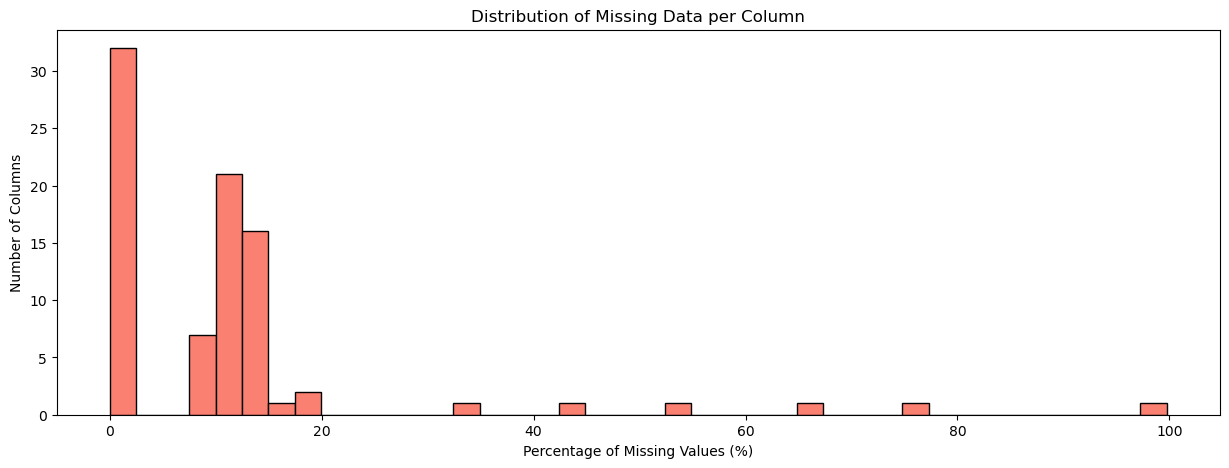

In [52]:
# Perform an assessment of how much missing data there is in each column of the
# dataset.

#Calculate percentage of missing values per column
missing_per_col = (azdias.isnull().sum() / len(azdias)) * 100

#Sort the values
missing_per_col = missing_per_col.sort_values(ascending=False)

#Plot distribution
plt.figure(figsize=(15,5))
plt.hist(missing_per_col, bins=40, color='salmon', edgecolor='black')
plt.xlabel('Percentage of Missing Values (%)')
plt.ylabel('Number of Columns')
plt.title('Distribution of Missing Data per Column')
plt.show()

In [53]:
# Investigate patterns in the amount of missing data in each column.
azdias.shape

(891221, 85)

In [54]:
# Remove the outlier columns from the dataset. (You'll perform other data
# engineering tasks such as re-encoding and imputation later.)
#Setting threshold
threshold= 30

#Identify outlier columns
outlier_cols = missing_per_col[missing_per_col > threshold].index.tolist()
print('Columns to drop:', outlier_cols)

#Drop outlier columns from dataset
azdias = azdias.drop(columns=outlier_cols)


Columns to drop: ['TITEL_KZ', 'AGER_TYP', 'KK_KUNDENTYP', 'KBA05_BAUMAX', 'GEBURTSJAHR', 'ALTER_HH']


#### Discussion 1.1.2: Assess Missing Data in Each Column

The histogram of missing data across all 85 columns reveals a strongly right-skewed distribution. The bulk of features cluster between 0–20% missing values, with a large spike of roughly 32 columns having near-zero missing values. Beyond 20%, the distribution drops sharply, leaving a visible gap before a sparse tail of extreme outliers; several columns are missing anywhere from 30% to nearly 100% of their values.

This gap served as a natural threshold. Imputing columns with heavily absent values would introduce far more noise than signal, risking meaningful distortion in any downstream modeling. A cutoff of 30% was therefore applied, resulting in the removal of the following 6 columns: TITEL_KZ, AGER_TYP, KK_KUNDENTYP, KBA05_BAUMAX, GEBURTSJAHR, and ALTER_HH. The remaining features all fell within an acceptable range of missingness that can be handled through standard imputation techniques.

#### Step 1.1.3: Assess Missing Data in Each Row

How much data is missing in each row? As with the columns, you should see some groups of points that have a very different numbers of missing values. Divide the data into two subsets: one for data points that are above some threshold for missing values, and a second subset for points below that threshold.

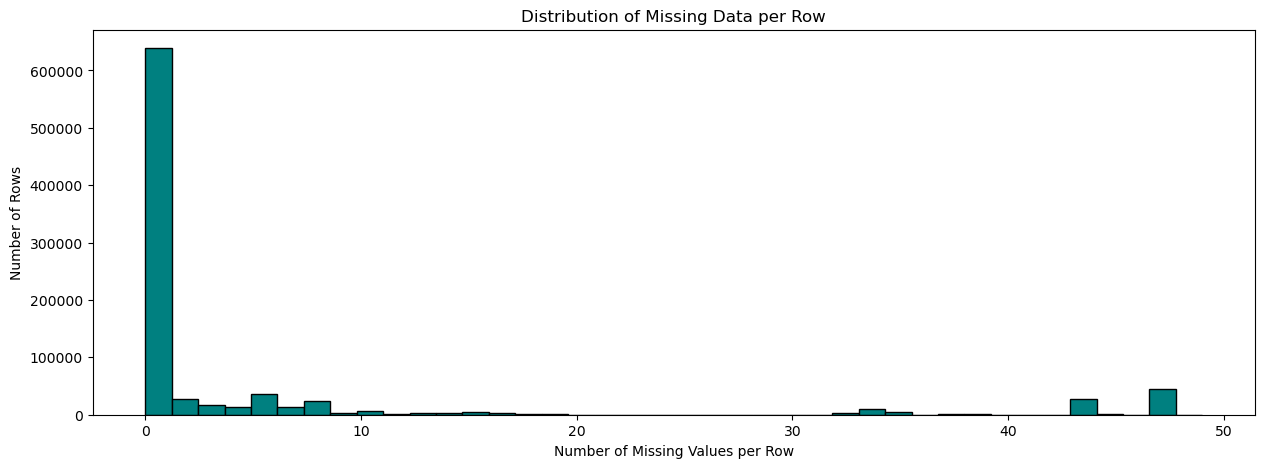

In [55]:
# How much data is missing in each row of the dataset?
#Calculate number of missing values per row
missing_per_row = azdias.isnull().sum(axis=1)

#Plot distribution
plt.figure(figsize=(15,5))
plt.hist(missing_per_row, bins=40, color='teal', edgecolor='black')
plt.xlabel('Number of Missing Values per Row')
plt.ylabel('Number of Rows')
plt.title('Distribution of Missing Data per Row')
plt.show()

In [56]:
# Write code to divide the data into two subsets based on the number of missing
# values in each row.

#Setting threshold
row_threshold = 30

#Divide data into two subsets
azdias_low_missing = azdias[missing_per_row <= row_threshold]
azdias_high_missing = azdias[missing_per_row > row_threshold]

print(f"Rows with low missing data: {len(azdias_low_missing)}")
print(f"Rows with high missing data: {len(azdias_high_missing)}")



Rows with low missing data: 798067
Rows with high missing data: 93154


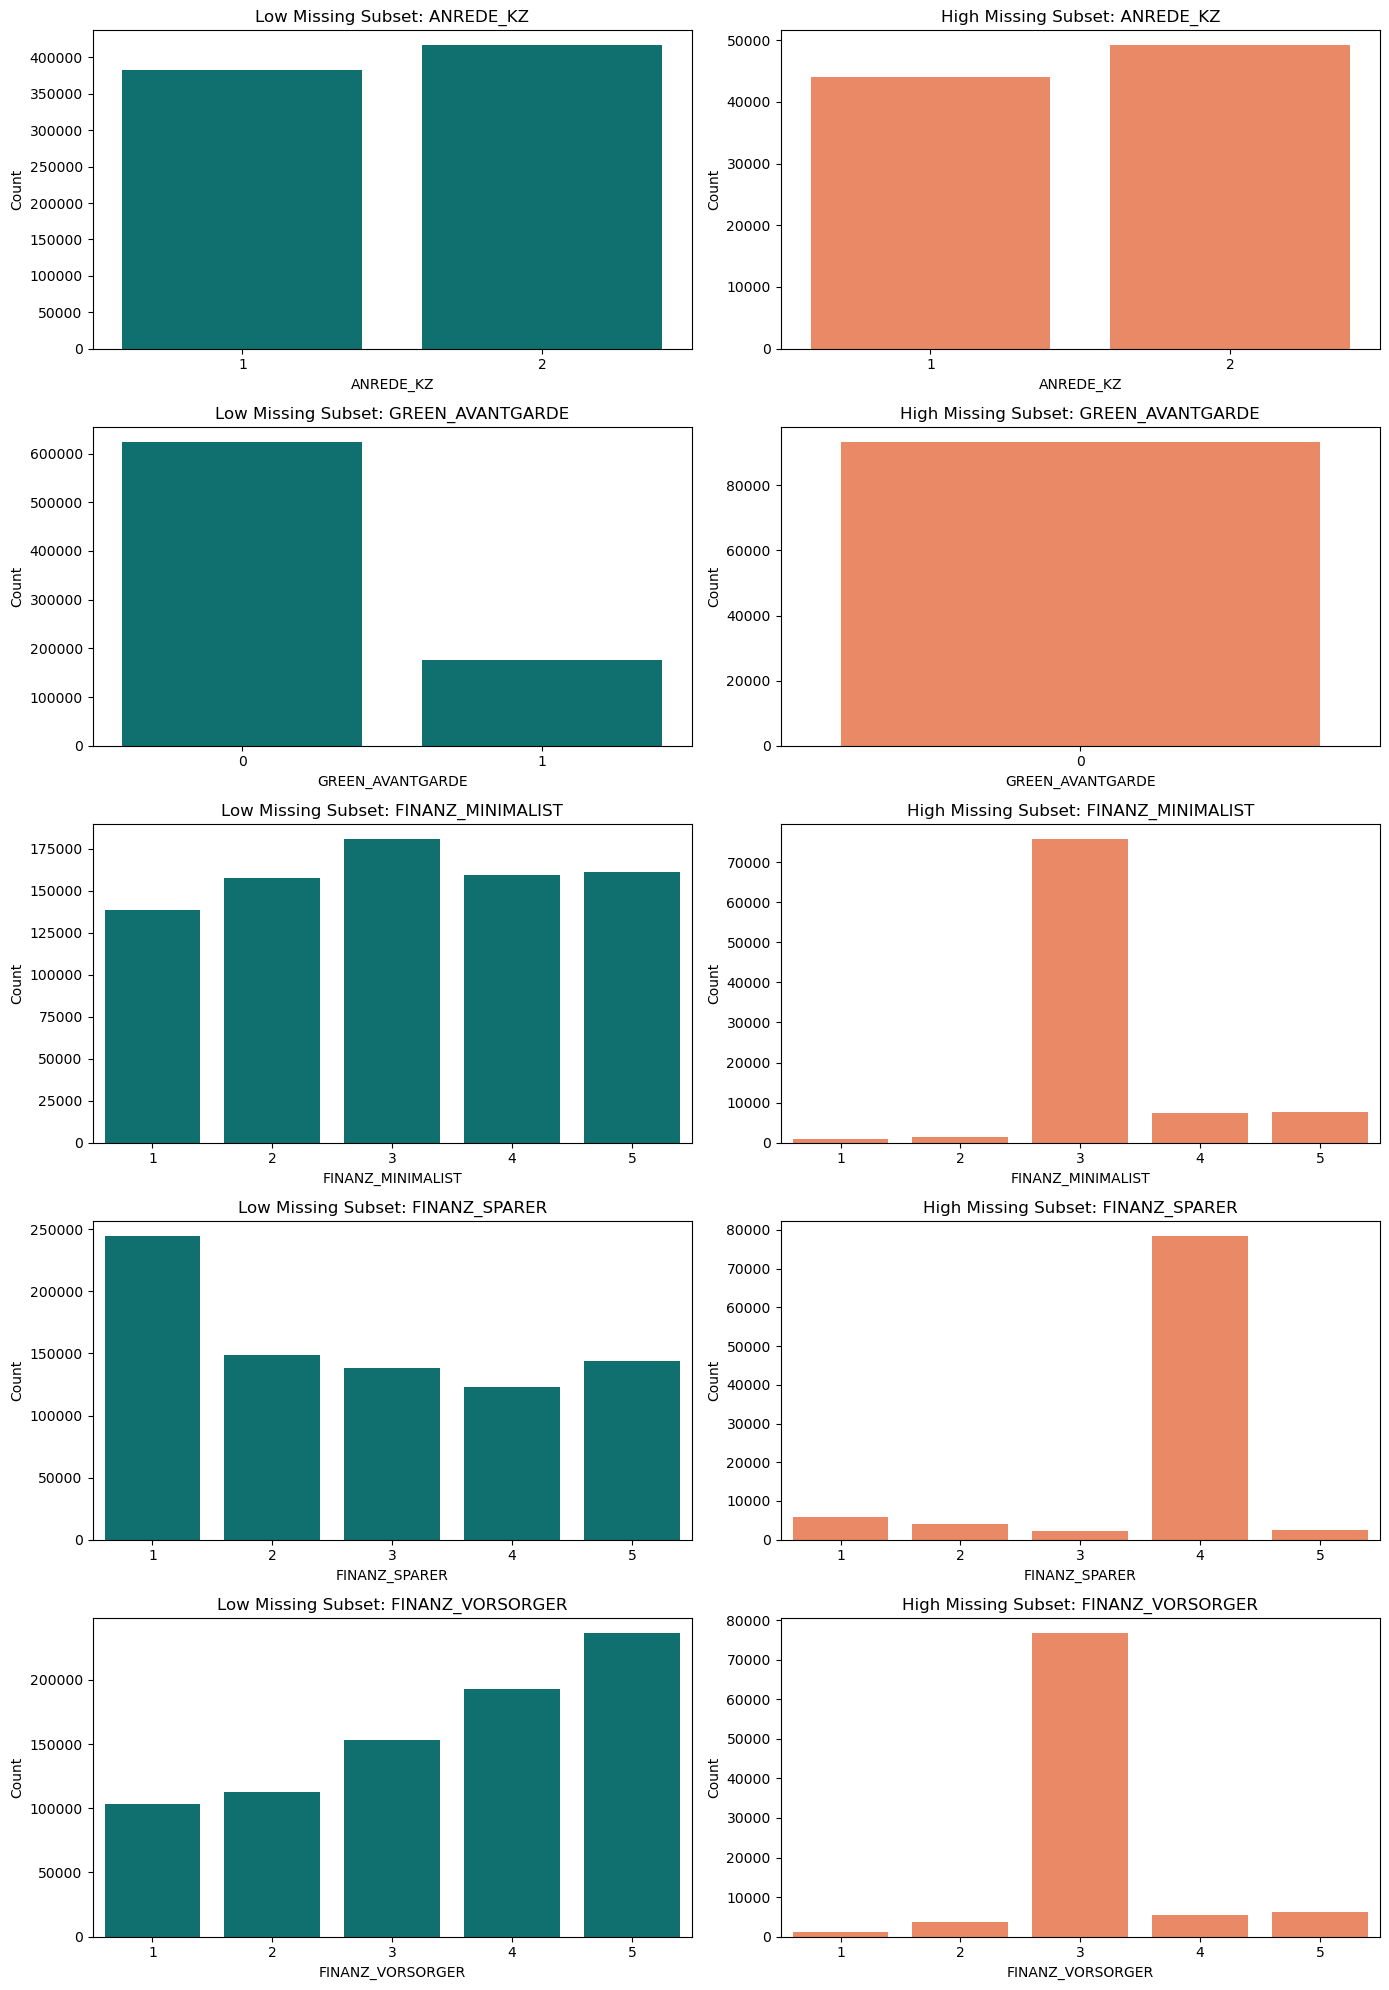

In [57]:
# Compare the distribution of values for at least five columns where there are
# no or few missing values, between the two subsets.

#Pick 5 columns known to have zero/few missing values in this dataset
compare_cols = ['ANREDE_KZ', 'GREEN_AVANTGARDE', 'FINANZ_MINIMALIST', 'FINANZ_SPARER', 'FINANZ_VORSORGER']

# Set up a grid of plots: 5 rows (one for each column) and 2 columns (low missing vs. high missing)
fig, axes = plt.subplots(nrows=len(compare_cols), ncols=2, figsize=(14, 20))

for i, col in enumerate(compare_cols):
    # Plot the Low Missing subset on the left
    sns.countplot(data=azdias_low_missing, x=col, ax=axes[i, 0], color='teal')
    axes[i, 0].set_title(f'Low Missing Subset: {col}')
    axes[i, 0].set_ylabel('Count')
    
    # Plot the High Missing subset on the right
    sns.countplot(data=azdias_high_missing, x=col, ax=axes[i, 1], color='coral')
    axes[i, 1].set_title(f'High Missing Subset: {col}')
    axes[i, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()

#### Discussion 1.1.3: Assess Missing Data in Each Row

The countplots reveal stark distributional differences between the low-missing and high-missing subsets across nearly all features. In variables such as FINANZ_MINIMALIST and FINANZ_SPARER, the high-missing subset is almost entirely concentrated at value 3, while the low-missing subset exhibits a far broader, more balanced spread across all categories. A similar pattern emerges in FINANZ_VORSORGER and GREEN_AVANTGARDE, where the high-missing subset collapses to a single dominant value rather than reflecting any meaningful variation. This systematic divergence strongly indicates that the missing data is not missing at random (MNAR); the absence of responses is itself informative, pointing to a structurally distinct subgroup within the population.

Retaining these individuals and imputing their missing values would have been methodologically unsound: artificially reconstructing their feature distributions would have introduced a distorted, homogeneous cluster into the segmentation that does not reflect any genuine customer archetype. Separating the high-missing subset before clustering was therefore not merely a data-cleaning convenience, but a necessary step to preserve the integrity and interpretability of the resulting segments.

### Step 1.2: Select and Re-Encode Features

Checking for missing data isn't the only way to prepare a dataset for analysis. Since the unsupervised learning techniques to be used will only work on data that is encoded numerically, I made a few encoding changes or additional assumptions to be able to make progress. In addition, while almost all of the values in the dataset are encoded using numbers, not all of them represent numeric values. Check the third column of the feature summary (`feat_info`) for a summary of types of measurement.
- For numeric and interval data, these features can be kept without changes.
- Most of the variables in the dataset are ordinal in nature. While ordinal values may technically be non-linear in spacing, make the simplifying assumption that the ordinal variables can be treated as being interval in nature (that is, kept without any changes).
- Special handling may be necessary for the remaining two variable types: categorical, and 'mixed'.

In the first two parts of this sub-step, I performed an investigation of the categorical and mixed-type features and made a decision on each of them, whether to keep, drop, or re-encode each. Then, in the last part, I will create a new data frame with only the selected and engineered columns.

Data wrangling is often the trickiest part of the data analysis process, and there's a lot of it to be done here. But eventually we'll be ready to get to the machine learning parts of the project!

In [73]:
# How many features are there of each data type?

#Filter feature summary to include the columns remaining in our dataset
features_kept = feat_info[feat_info['attribute'].isin(azdias_low_missing.columns)]

#Count the occurrences for each data type
type_counts = features_kept['type'].value_counts()

print("Number of features by data type:")
print(type_counts)

Number of features by data type:
type
ordinal        49
categorical    18
mixed           6
numeric         6
Name: count, dtype: int64


#### Step 1.2.1: Re-Encode Categorical Features

For categorical data, you would ordinarily need to encode the levels as dummy variables. Depending on the number of categories, I was asked to perform one of the following:
- For binary (two-level) categoricals that take numeric values, you can keep them without needing to do anything.
- There is one binary variable that takes on non-numeric values. For this one, you need to re-encode the values as numbers or create a dummy variable.
- For multi-level categoricals (three or more values), you can choose to encode the values using multiple dummy variables (e.g. via [OneHotEncoder](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html)), or (to keep things straightforward) just drop them from the analysis. As always, document your choices in the Discussion section.

In [74]:
# Assess categorical variables: which are binary, which are multi-level, and
# which one needs to be re-encoded?

#Extract the categorical features from feature summary
categorical_features = feat_info[feat_info['type'] == 'categorical']['attribute'].values

#Filter out the outlier columns
categorical_features = [col for col in categorical_features if col in azdias_low_missing.columns]

#Lists for seperated features
binary_features = []
multi_level_features = []

#Loop through categorical features and check unique values
for col in categorical_features:

    if azdias_low_missing[col].dropna().nunique() > 2:
        binary_features.append(col)  



In [75]:
# Re-encode categorical variable(s) to be kept in the analysis.
#Map string values in OST_WEST_KZ to ints
azdias_low_missing.loc[:, 'OST_WEST_KZ'] = azdias_low_missing['OST_WEST_KZ'].map({'W':1,'O':0})

#One-hot encode multi-level features
azdias_low_missing = pd.get_dummies(azdias_low_missing, columns=multi_level_features)

#Print
print('New dataset shape:', azdias_low_missing.shape)


New dataset shape: (798067, 79)


#### Discussion 1.2.1: Re-Encode Categorical Features

To prepare the categorical features for modeling, each variable was first classified as either binary or multi-level. Dropping 'NaN' values and finding unique values in the dataset seemed necessary. The majority of binary features were already numerically encoded and required no further transformation. The sole exception was OST_WEST_KZ, which stored its values as strings ('W' and 'O'); these were remapped to 1 and 0 respectively to bring the column in line with the rest of the binary features.

For multi-level categorical variables, one-hot encoding was applied using pd.get_dummies(), expanding each category into its own binary indicator column. This avoids imposing any artificial ordinal relationship between category levels, which would otherwise misrepresent the data to distance-based algorithms like K-Means. Following these transformations, the dataset expanded from 79 to the updated column count reflected in the new shape of (798,067 x 79).

#### Step 1.2.2: Engineer Mixed-Type Features

There are a handful of features that are marked as "mixed" in the feature summary that require special treatment in order to be included in the analysis. There are two in particular that deserve attention.

- "PRAEGENDE_JUGENDJAHRE" combines information on three dimensions: generation by decade, movement (mainstream vs. avantgarde), and nation (east vs. west). While there aren't enough levels to disentangle east from west, I should create two new variables to capture the other two dimensions: an interval-type variable for decade, and a binary variable for movement.

- "CAMEO_INTL_2015" combines information on two axes: wealth and life stage. Break up the two-digit codes by their 'tens'-place and 'ones'-place digits into two new ordinal variables (which, for the purposes of this project, is equivalent to just treating them as their raw numeric values).



In [76]:
# Investigate "PRAEGENDE_JUGENDJAHRE" and engineer two new variables.
#Modify PRAEGENDE_JUGENDJAHRE
#Map decades (1=40s, 2=50s, 3= 60s ....)
decade_dict= {1:1, 2:1, 3:2, 4:2, 5:3, 6:3, 7:3, 8:4, 9:4, 10:5, 11:5, 12:5, 13:5, 14:6,15:6}
#Map movements (0 = mainstream, 1= Avantgarde)
movement_dict = {1:0, 2:1, 3:0, 4:1, 5:0, 6:1, 7:1, 8:0, 9:1, 10:0, 11:1, 12:0, 13:1, 14:0, 15:1}

azdias_low_missing['DECADE'] = azdias_low_missing['PRAEGENDE_JUGENDJAHRE'].map(decade_dict)
azdias_low_missing['MOVEMENT'] = azdias_low_missing['PRAEGENDE_JUGENDJAHRE'].map(movement_dict)


In [77]:
# Investigate "CAMEO_INTL_2015" and engineer two new variables.
#CAMEO_INTL_2015

def extract_wealth(x):
    try:
        return int(str(x)[0])
    except:
        return np.nan

def extract_lifestage(x):
    try:
        return int(str(x)[1])
    except:
        return np.nan

azdias_low_missing['WEALTH'] = azdias_low_missing['CAMEO_INTL_2015'].apply(extract_wealth)
azdias_low_missing['LIFE_STAGE'] = azdias_low_missing['CAMEO_INTL_2015'].apply(extract_lifestage)

#### Discussion 1.2.2: Engineer Mixed-Type Features

For PRAEGENDE_JUGENDJAHRE, the original codes encoded three dimensions simultaneously. Two dimensions were extracted into separate variables: DECADE, mapped from the original codes to the corresponding generational decade (1=40s, 2=50s, 3=60s, etc.), and MOVEMENT, a binary indicator distinguishing Mainstream (0) from Avantgarde (1). Both were derived using explicit lookup dictionaries to ensure accurate and transparent mapping.

For CAMEO_INTL_2015, the two-digit codes were decomposed by positional digit, the tens-place yielding WEALTH and the ones-place yielding LIFE_STAGE, each treated as a raw ordinal numeric value. A helper function with error handling was used to safely extract each digit, returning NaN for any unparseable entries rather than raising exceptions.

Following extraction, all original mixed-type columns were dropped from the dataset to eliminate redundancy. Additionally, CAMEO_DEU_2015 and CAMEO_DEUG_2015 were explicitly removed, as their string-type values would have caused the StandardScaler to fail during the scaling phase.

#### Step 1.2.3: Complete Feature Selection

In order to finish this step up, I needed to make sure that the data frame now only has the columns that I want to keep. To summarize, the dataframe should consist of the following:

- All numeric, interval, and ordinal type columns from the original dataset.
- Binary categorical features (all numerically-encoded).
- Engineered features from other multi-level categorical features and mixed features.


In [ ]:

#Drop all the original mixed-type features to clean up
mixed_features = feat_info[feat_info['type'] == 'mixed']['attribute'].values
cols_to_drop = [col for col in mixed_features if col in azdias_low_missing.columns]


In [79]:
# Do whatever you need to in order to ensure that the dataframe only contains
# the columns that should be passed to the algorithm functions.

azdias_low_missing = azdias_low_missing.drop(columns=cols_to_drop)

print("Final cleaned dataset shape:", azdias_low_missing.shape)

Final cleaned dataset shape: (798067, 77)


### Step 1.3: Create a Cleaning Function

Even though I've finished cleaning up the general population demographics data, it's important to look ahead to the future and realize that I will need to perform the same cleaning steps on the customer demographics data. So, in this substep, I created a function to execute the main feature selection, encoding, and re-engineering steps I performed above. Then, when it comes to looking at the customer data in Step 3, I can just run this function on that DataFrame to get the trimmed dataset in a single step.

In [80]:
#Preprocessing / Cleaning function

def clean_data(df):
    '''
    Perform feature trimming, re-encoding, and engineering for demographics data

    INPUT: Demographics DataFrame
    OUTPUT: Trimmed and cleaned demographics DataFrame
    '''
    df= df.copy()


    #Create a dictionary for storing mapping
    missing_dict = {}
    
    for index, row in feat_info.iterrows():
        attribute = row['attribute']
    
        #Strip brackets and split comma
        missing_str = row['missing_or_unknown'].strip('[]').split(',')
    
        missing_vals = []
        for val in missing_str:
            if val != '': #Try to convert numeric strings to integers
                try:
                    missing_vals.append(int(val))
                except ValueError:
                    missing_vals.append(val)
    
        #Add cleaned list to dictionary
        missing_dict[attribute]= missing_vals     


    
    # 1. Convert missing value codes into NaNs
    for col in df.columns:
        if col in missing_dict:
            df[col] = df[col].replace(missing_dict[col], np.nan)
            
    # 2. Remove selected outlier columns
    outlier_cols = ['TITEL_KZ', 'AGER_TYP', 'KK_KUNDENTYP', 'KBA05_BAUMAX', 'GEBURTSJAHR', 'ALTER_HH']
    df = df.drop(columns=outlier_cols, errors='ignore')
    
    #Setting threshold
    threshold= 30
    missing_per_row = df.isnull().sum(axis=1)
    df= df[missing_per_row <= threshold]
    
    # 3. Map the 'OST_WEST_KZ' column to 0s and 1s
    df.loc[:, 'OST_WEST_KZ'] = df['OST_WEST_KZ'].map({'W':1,'O':0})
    
    
    # 4. Engineer the 'PRAEGENDE_JUGENDJAHRE' and 'CAMEO_INTL_2015' features
    #Modify PRAEGENDE_JUGENDJAHRE
    #Map decades (1=40s, 2=50s, 3= 60s ....)
    decade_dict= {1:1, 2:1, 3:2, 4:2, 5:3, 6:3, 7:3, 8:4, 9:4, 10:5, 11:5, 12:5, 13:5, 14:6,15:6}
    #Map movements (0 = mainstream, 1= Avantgarde)
    movement_dict = {1:0, 2:1, 3:0, 4:1, 5:0, 6:1, 7:1, 8:0, 9:1, 10:0, 11:1, 12:0, 13:1, 14:0, 15:1}

    df['DECADE'] = df['PRAEGENDE_JUGENDJAHRE'].map(decade_dict)
    df['MOVEMENT'] = df['PRAEGENDE_JUGENDJAHRE'].map(movement_dict)

    #CAMEO_INTL_2015

    def extract_wealth(x):
        try:
            return int(str(x)[0])
        except:
            return np.nan

    def extract_lifestage(x):
        try:
            return int(str(x)[1])
        except:
            return np.nan

    
    df['WEALTH'] = df['CAMEO_INTL_2015'].apply(extract_wealth)
    df['LIFE_STAGE'] = df['CAMEO_INTL_2015'].apply(extract_lifestage)

    #Drop all the original mixed-type features to clean up
    mixed_features = feat_info[feat_info['type'] == 'mixed']['attribute'].values
    cols_to_drop = [col for col in mixed_features if col in df.columns]

    df = df.drop(columns=cols_to_drop)
    
    # 5. Drop the original multi-level categorical and mixed features 
    # (Note: pd.get_dummies is usually applied outside the function or carefully 
    # mapped inside to ensure both datasets get the exact same columns)

    #One-hot encode multi-level features
    df = pd.get_dummies(df, columns=multi_level_features)
    
    return df
    

In [81]:
clean_azdias = clean_data(azdias)

## Step 2: Feature Transformation

### Step 2.1: Apply Feature Scaling

Before we apply dimensionality reduction techniques to the data, we need to perform feature scaling so that the principal component vectors are not influenced by the natural differences in scale for features. Starting from this part of the project, I'll want to keep an eye on the [API reference page for sklearn](http://scikit-learn.org/stable/modules/classes.html) to help navigate to all of the classes and functions that I'll need. In this substep, I'll need to check the following:

- sklearn requires that data not have missing values in order for its estimators to work properly. So, before applying the scaler to the data, I'll make sure I have cleaned the DataFrame of the remaining missing values. This can be as simple as just removing all data points with missing data, or applying an [Imputer](https://scikit-learn.org/0.16/modules/generated/sklearn.preprocessing.Imputer.html) to replace all missing values. 

- For the actual scaling function, a [StandardScaler](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) instance is suggested, scaling each feature to mean 0 and standard deviation 1.

- For these classes, I can make use of the `.fit_transform()` method to both fit a procedure to the data as well as apply the transformation to the data at the same time.

In [ ]:

# Drop the redundant CAMEO string columns
clean_azdias = clean_azdias.drop(columns=['CAMEO_DEU_2015', 'CAMEO_DEUG_2015'], errors='ignore')

#Impute missing values using mode of each column
imputer = SimpleImputer(strategy='most_frequent')
azdias_imputed = imputer.fit_transform(clean_azdias)


In [83]:
# Apply feature scaling to the general population demographics data.
#Apply feature scaling sop all columns have a mean of 0 and std of 1
scaler = StandardScaler()
azdias_scaled = scaler.fit_transform(azdias_imputed)

#Convert arrays to DataFrames; keeping things readable
azdias_scaled = pd.DataFrame(azdias_scaled, columns = clean_azdias.columns)

#Verify shape and NaNs are gone
print('Scaled dataset shape:', azdias_scaled.shape)
print('Remaining missing values:', azdias_scaled.isnull().sum().sum())


Scaled dataset shape: (798067, 75)
Remaining missing values: 0


### Discussion 2.1: Apply Feature Scaling

Observations:

Since the typical machine learning algorithms in sklearn can't deal with missing data, I started by using a SimpleImputer to replace any leftover NaN values with the most common value (the mode) in each column. After filling in the gaps, I used a StandardScaler. This step was important because the features varied widely in their scales (like birth years compared to ratings on a 1-to-5 scale). Standardizing the data makes sure every feature has a mean of 0 and a standard deviation of 1, which stops features with bigger numeric ranges from overpowering the Principal Component Analysis.

### Step 2.2: Perform Dimensionality Reduction

On my scaled data, I am now ready to apply dimensionality reduction techniques.


In [84]:
# Apply PCA to the data.
#Instantiate PCA with same number of components as features
pca = PCA()
pca.fit(azdias_scaled)


,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


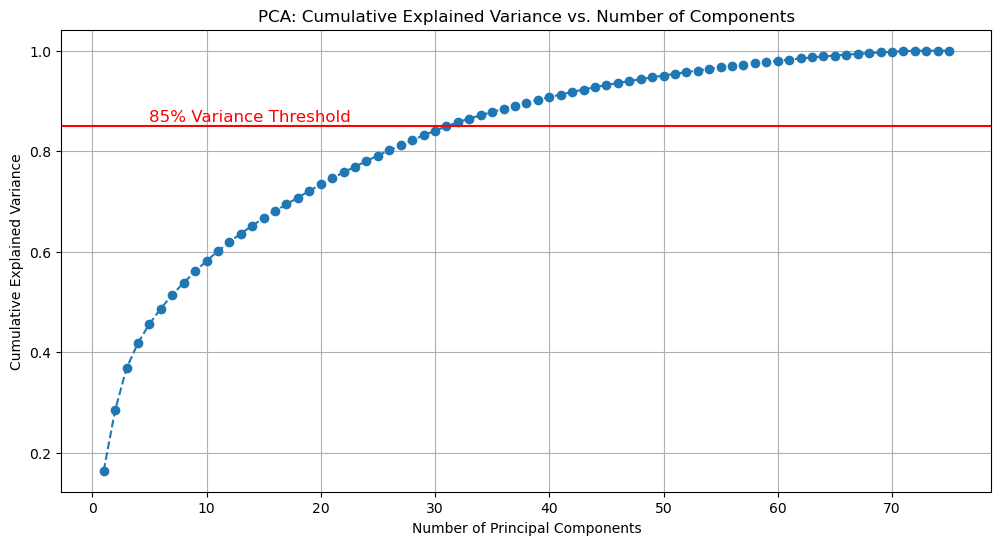

In [85]:
# Investigate the variance accounted for by each principal component.
#Calculate cumulative explained variance
cum_variance = np.cumsum(pca.explained_variance_ratio_)

#Plot cumulative explained variance
plt.figure(figsize=(12,6))
plt.plot(range(1, len(cum_variance) +1), cum_variance, marker='o', linestyle='--')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA: Cumulative Explained Variance vs. Number of Components')
plt.grid(True)
plt.axhline(y=0.85, color='r', linestyle='-') #Reference line
plt.text(5, 0.86, '85% Variance Threshold', color='red', fontsize=12)
plt.show()

In [86]:
# Re-apply PCA to the data while selecting for number of components to retain.

#Re-instantiate PCA with 85% variance threshold
pca_85 = PCA(n_components=0.85, random_state=42)
azdias_pca = pca_85.fit_transform(azdias_scaled)

print(f'Original number of features: {azdias_scaled.shape[1]}')
print(f'Reduced number of features: {azdias_pca.shape[1]}')

Original number of features: 75
Reduced number of features: 32


### Discussion 2.2: Perform Dimensionality Reduction

Observations:
I utilized Principal Component Analysis (PCA) to effectively reduce the dimensionality of the scaled dataset.

By graphing the cumulative explained variance as a function of the number of principal components, I was able to pinpoint the "elbow" point on the curve, which guided my selection process.

I decided to retain components that account for 85% of the total variance, a choice that substantially decreased the number of features. This threshold strikes an optimal balance by maintaining the majority of the essential information embedded within the dataset, while simultaneously enhancing computational efficiency for the subsequent clustering model. This approach ensures that the model can operate more swiftly without sacrificing critical data characteristics.

### Step 2.3: Interpret Principal Components

Now that we have our transformed principal components, it's a nice idea to check out the weight of each variable on the first few components to see if they can be interpreted in some fashion.

Each principal component is a unit vector that points in the direction of highest variance (after accounting for the variance captured by earlier principal components). The further a weight is from zero, the more the principal component is in the direction of the corresponding feature. If two features have large weights of the same sign (both positive or both negative), then increases in one tend expect to be associated with increases in the other. To contrast, features with different signs can be expected to show a negative correlation: increases in one variable should result in a decrease in the other.

- To investigate the features, I should map each weight to their corresponding feature name, then sort the features according to weight. The most interesting features for each principal component, then, will be those at the beginning and end of the sorted list. Use the data dictionary document to help me understand these most prominent features, their relationships, and what a positive or negative value on the principal component might indicate.
- I  should investigate and interpret feature associations from the first three principal components in this substep.

In [ ]:
# Map weights for the first principal component to corresponding feature names
# and then print the linked values, sorted by weight.


def map_weights(pca_model, component_num, feature_names):
    #Create dataframe of PCA weights
    weights = pd.DataFrame(pca_model.components_, columns=feature_names)

    #Isolate requested components and sort weights
    component_weights = weights.iloc[component_num].sort_values(ascending=False)
    return component_weights

#Interpret first principal component
component_0 = map_weights(pca_85, 0, azdias_scaled.columns)

print("Top positive weights for Component 1:")
print(component_0.head(5))
print("\nTop negative weights for Component 1:")
print(component_0.tail(5))

Top positive weights for Component 1:
LP_STATUS_FEIN       0.227397
LP_STATUS_GROB       0.227318
FINANZ_MINIMALIST    0.216989
MOBI_REGIO           0.209553
PLZ8_ANTG1           0.202942
Name: 0, dtype: float64

Top negative weights for Component 1:
ORTSGR_KLS9          -0.173670
WEALTH               -0.190860
PLZ8_ANTG4           -0.194873
HH_EINKOMMEN_SCORE   -0.200477
PLZ8_ANTG3           -0.202465
Name: 0, dtype: float64


In [88]:
# Map weights for the second principal component to corresponding feature names
# and then print the linked values, sorted by weight.

# Interpret Component 2 (index 1)
print(map_weights(pca_85, 1, azdias_scaled.columns).head(5))
print(map_weights(pca_85, 1, azdias_scaled.columns).tail(5))

ALTERSKATEGORIE_GROB    0.254986
FINANZ_VORSORGER        0.227985
SEMIO_ERL               0.221999
SEMIO_LUST              0.177537
RETOURTYP_BK_S          0.160722
Name: 1, dtype: float64
SEMIO_TRADV             -0.225183
FINANZ_UNAUFFAELLIGER   -0.226471
FINANZ_SPARER           -0.233980
DECADE                  -0.239341
SEMIO_REL               -0.249784
Name: 1, dtype: float64


In [89]:
# Map weights for the third principal component to corresponding feature names
# and then print the linked values, sorted by weight.

# Interpret Component 3 (index 2)
print(map_weights(pca_85, 2, azdias_scaled.columns).head(5))
print(map_weights(pca_85, 2, azdias_scaled.columns).tail(5))

ANREDE_KZ     0.362322
SEMIO_KAEM    0.330164
SEMIO_DOM     0.307374
SEMIO_KRIT    0.271281
SEMIO_RAT     0.201244
Name: 2, dtype: float64
FINANZ_MINIMALIST   -0.142258
SEMIO_KULT          -0.240750
SEMIO_FAM           -0.254189
SEMIO_SOZ           -0.260086
SEMIO_VERT          -0.335477
Name: 2, dtype: float64


### Discussion 2.3: Interpret Principal Components

**Component 1: Socioeconomic Status & Neighborhood Density**

Component 1 captures a contrast between wealth, income, and urban housing density on one side, and financial minimalism, low mobility, and rural/suburban housing on the other.

Negative weights WEALTH and HH_EINKOMMEN_SCORE (high wealth/urban end), indicates higher household income and financial standing, while PLZ8_ANTG3 and PLZ8_ANTG4 reflect neighborhoods dominated by larger multi-family housing; typical of denser, urban environments.

The positive weights were LP_STATUS_FEIN and LP_STATUS_GROB (low income/rural end). They reflect lower social status tiers, FINANZ_MINIMALIST indicates little financial engagement or interest, MOBI_REGIO points to low regional mobility, and PLZ8_ANTG1 reflects areas with predominantly small, 1–2 family homes characteristic of rural or suburban settings.

Component 1 is best interpreted as a Socioeconomic & Urbanization axis. High scores on this component correspond to lower-income, low-mobility individuals in small-home, rural/suburban neighborhoods. Low scores correspond to wealthier individuals in higher-density, multi-family urban areas.

**Component 2: Age & Personality Orientation**

Component 2 captures a generational and personality contrast between traditional, conservative values on one side, and event-driven, experiential attitudes on the other.

Negative weights (younger/traditional end): DECADE reflects earlier birth decades (i.e., older generations encoded as lower numeric values), SEMIO_REL and SEMIO_TRADV indicate religious and traditional-minded personalities, and FINANZ_SPARER and FINANZ_UNAUFFAELLIGER suggest cautious, savings-oriented financial behavior.

Positive weights (older/experiential end): ALTERSKATEGORIE_GROB directly reflects estimated age category, while SEMIO_ERL and SEMIO_LUST point to event-oriented and sensual/experiential personalities. FINANZ_VORSORGER suggests future-oriented financial planning, and RETOURTYP_BK_S reflects a particular return-buying behavior pattern.

Component 2 is best interpreted as an Age & Lifestyle Orientation axis. High scores reflect older individuals with experiential, pleasure-seeking personalities and proactive financial planning. Low scores reflect younger individuals with more traditional, religious, and financially conservative profiles.

**Component 3: Gender & Personality/Social Orientation**

Component 3 captures a strong contrast between assertive, dominant personality traits on one side, and socially nurturing, family-oriented traits on the other; with gender as the single strongest driver.

Positive weights (assertive/dominant end): ANREDE_KZ (gender indicator) is the dominant feature here, suggesting this component strongly correlates with a particular gender grouping. This is reinforced by personality traits SEMIO_KAEM (combative), SEMIO_DOM (dominant), SEMIO_KRIT (critical-minded), and SEMIO_RAT (rational), painting a profile of assertive, independent-minded individuals.

Negative weights (social/nurturing end): SEMIO_VERT (dreamful), SEMIO_SOZ (socially-minded), SEMIO_FAM (family-oriented), and SEMIO_KULT (culturally-minded) cluster together on the opposite end, reflecting individuals who prioritize community, relationships, and creativity over dominance or competition.

Component 3 is best interpreted as a Gender & Social Personality axis. High scores reflect individuals who skew toward assertive, critical, and dominant personality profiles. Low scores reflect individuals who lean toward social connectedness, family values, and cultural engagement.

## Step 3: Clustering

### Step 3.1: Apply Clustering to General Population

I have assessed and cleaned the demographics data, then scaled and transformed them. Now, it's time to see how the data clusters in the principal components space. In this substep, I will apply k-means clustering to the dataset and use the average within-cluster distances from each point to their assigned cluster's centroid to decide on a number of clusters to keep.

- Use sklearn's [KMeans](http://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html#sklearn.cluster.KMeans) class to perform k-means clustering on the PCA-transformed data.
- Then, compute the average difference from each point to its assigned cluster's center. **Hint**: The KMeans object's `.score()` method might be useful here, but note that in sklearn, scores tend to be defined so that larger is better. Try applying it to a small, toy dataset, or use an internet search to help your understanding.
- Perform the above two steps for a number of different cluster counts. You can then see how the average distance decreases with an increasing number of clusters. However, each additional cluster provides a smaller net benefit. Use this fact to select a final number of clusters in which to group the data. **Warning**: because of the large size of the dataset, it can take a long time for the algorithm to resolve. The more clusters to fit, the longer the algorithm will take. You should test for cluster counts through at least 10 clusters to get the full picture, but you shouldn't need to test for a number of clusters above about 30.
- Once you've selected a final number of clusters to use, re-fit a KMeans instance to perform the clustering operation. Make sure that you also obtain the cluster assignments for the general demographics data, since you'll be using them in the final Step 3.3.

In [90]:
# Over a number of different cluster counts...
# Take a random 20% sample of the PCA data to speed up the Elbow Method
np.random.seed(42)
sample_indices = np.random.choice(azdias_pca.shape[0], int(azdias_pca.shape[0] * 0.2), replace=False)
azdias_sample = azdias_pca[sample_indices]

# Test cluster counts from 1 to 20 (stepping by 2 to save time)
centers = list(range(1, 20, 2))
scores = []

    # run k-means clustering on the data and...
for center in centers:
    # Initialize K-Means
    kmeans = KMeans(n_clusters=center, random_state=42)
    # Fit the model
    model = kmeans.fit(azdias_sample)
    # Calculate the SSE (score returns a negative value, so we take the absolute)
    score = np.abs(model.score(azdias_sample))
    scores.append(score)

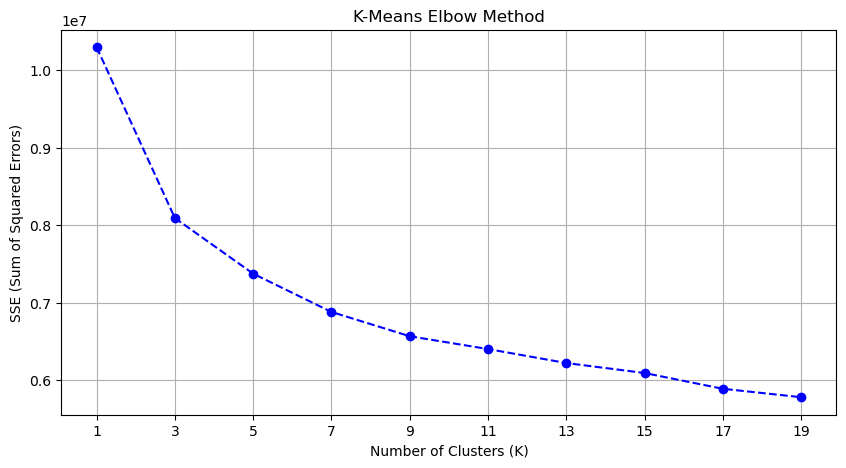

In [91]:
# Investigate the change in within-cluster distance across number of clusters.
# HINT: Use matplotlib's plot function to visualize this relationship.

plt.figure(figsize=(10, 5))
plt.plot(centers, scores, linestyle='--', marker='o', color='b')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('SSE (Sum of Squared Errors)')
plt.title('K-Means Elbow Method')
plt.xticks(centers)
plt.grid(True)
plt.show()

In [94]:
# Re-fit the k-means model with the selected number of clusters and obtain
# cluster predictions for the general population demographics data.
kmeans_model = KMeans(n_clusters=12, random_state=42)

#Fit model to the full PCA transformed data
azdias_clusters = kmeans_model.fit_predict(azdias_pca)

print('Demographics clustering complete')
print(f'Cluster labels: {np.unique(azdias_clusters)}')


Demographics clustering complete
Cluster labels: [ 0  1  2  3  4  5  6  7  8  9 10 11]


### Discussion 3.1: Apply Clustering to General Population

Observations:

To determine the optimal number of clusters, I used the Elbow Method by plotting the Sum of Squared Errors (SSE) for cluster values ranging from 2 to 20. The plot showed a clear “elbow” around 12 clusters, where the reduction in SSE began to level off. Beyond this point, adding more clusters resulted in only marginal improvements. Based on this observation, I selected 12 clusters for the final K-Means model, as it provides a good balance between clustering performance and model complexity.

### Step 3.2: Apply All Steps to the Customer Data

Now that I have clusters and cluster centers for the general population, it's time to see how the customer data maps on to those clusters. Take care to not confuse this for re-fitting all of the models to the customer data. Instead, I am going to use the fits from the general population to clean, transform, and cluster the customer data. In the last step of the project, I will interpret how the general population fits apply to the customer data.

- Don't forget when loading in the customers data, that it is semicolon (`;`) delimited.
- Apply the same feature wrangling, selection, and engineering steps to the customer demographics using the `clean_data()` function created earlier. (We can assume that the customer demographics data has similar meaning behind missing data patterns as the general demographics data.)
- Use the sklearn objects from the general demographics data, and apply their transformations to the customers data. That is, I should not be using a `.fit()` or `.fit_transform()` method to re-fit the old objects, nor should I be creating new sklearn objects! Carry the data through the feature scaling, PCA, and clustering steps, obtaining cluster assignments for all of the data in the customer demographics data.

In [95]:
# Load in the customer demographics data.
customers = pd.read_csv('Udacity_CUSTOMERS_Subset.csv', sep=';')

#Clearn data using 'clean_data()'
customers_clean = clean_data(customers)

#Align columns to fix any one-hot encoding mismatches
#Find columns in clean demographics dataset but missing in customers
missing_cols = set(clean_azdias.columns) - set(customers_clean.columns)
for col in missing_cols:
    customers_clean[col]=0

#Ensure same order of columns as demographics data
customers_clean = customers_clean[clean_azdias.columns]

#Impute and scale (using transform, not fit_transform)
customers_imputed = imputer.transform(customers_clean)
customers_scaled = scaler.transform(customers_imputed)

#Convert back to dataframe
customers_scaled = pd.DataFrame(customers_scaled, columns= customers_clean.columns)

In [96]:
# Apply preprocessing, feature transformation, and clustering from the general
# demographics onto the customer data, obtaining cluster predictions for the
# customer demographics data.

#PCA dimensionality reduction
customers_pca = pca_85.transform(customers_scaled)

#Predict the clusters for the customer base using the fitted K-Means model
customers_clusters = kmeans_model.predict(customers_pca)

print("Customer clustering complete!")
print(f"Customer cluster labels: {np.unique(customers_clusters)}")

Customer clustering complete!
Customer cluster labels: [ 0  1  2  3  4  5  6  7  8  9 10 11]


### Step 3.3: Compare Customer Data to Demographics Data

At this point, I have clustered data based on demographics of the general population of Germany, and seen how the customer data for a mail-order sales company maps onto those demographic clusters. In this final substep, I will compare the two cluster distributions to see where the strongest customer base for the company is.

Consider the proportion of persons in each cluster for the general population, and the proportions for the customers. If we think the company's customer base to be universal, then the cluster assignment proportions should be fairly similar between the two. If there are only particular segments of the population that are interested in the company's products, then we should see a mismatch from one to the other. If there is a higher proportion of persons in a cluster for the customer data compared to the general population (e.g. 5% of persons are assigned to a cluster for the general population, but 15% of the customer data is closest to that cluster's centroid) then that suggests the people in that cluster to be a target audience for the company. On the other hand, the proportion of the data in a cluster being larger in the general population than the customer data (e.g. only 2% of customers closest to a population centroid that captures 6% of the data) suggests that group of persons to be outside of the target demographics.

Take a look at the following points in this step:

- Compute the proportion of data points in each cluster for the general population and the customer data. Visualizations will be useful here: both for the individual dataset proportions, but also to visualize the ratios in cluster representation between groups. Seaborn's [`countplot()`](https://seaborn.pydata.org/generated/seaborn.countplot.html) or [`barplot()`](https://seaborn.pydata.org/generated/seaborn.barplot.html) function could be handy.
  - Recall the analysis I performed in step 1.1.3 of the project, where I separated out certain data points from the dataset if they had more than a specified threshold of missing values. If found that this group was qualitatively different from the main bulk of the data, I should treat this as an additional data cluster in this analysis. Make sure to account for the number of data points in this subset, for both the general population and customer datasets, when making computations!
- Which cluster or clusters are overrepresented in the customer dataset compared to the general population? Select at least one such cluster and infer what kind of people might be represented by that cluster. Use the principal component interpretations from step 2.3 or look at additional components to help you make this inference. Alternatively, you can use the `.inverse_transform()` method of the PCA and StandardScaler objects to transform centroids back to the original data space and interpret the retrieved values directly.
- Perform a similar investigation for the underrepresented clusters. Which cluster or clusters are underrepresented in the customer dataset compared to the general population, and what kinds of people are typified by these clusters?

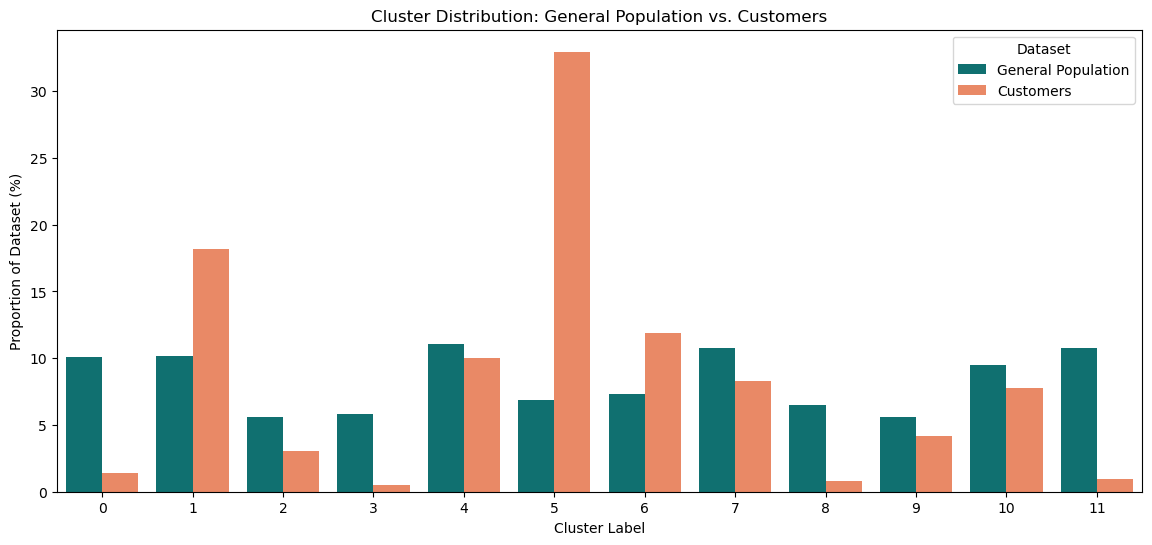

In [97]:
# Compare the proportion of data in each cluster for the customer data to the
# proportion of data in each cluster for the general population.

import seaborn as sns

# Calculate the percentage of people in each cluster for the General Population
pop_proportions = pd.Series(azdias_clusters).value_counts(normalize=True).sort_index() * 100

# Calculate the percentage of people in each cluster for the Customers
cust_proportions = pd.Series(customers_clusters).value_counts(normalize=True).sort_index() * 100

# Combine the data into a single DataFrame for clean plotting
proportions_df = pd.DataFrame({'General Population': pop_proportions, 'Customers': cust_proportions})
proportions_df['Cluster'] = proportions_df.index
proportions_df = proportions_df.melt(id_vars='Cluster', var_name='Dataset', value_name='Proportion (%)')

# Plot the side-by-side bar chart
plt.figure(figsize=(14, 6))
sns.barplot(x='Cluster', y='Proportion (%)', hue='Dataset', data=proportions_df, palette=['teal', 'coral'])
plt.title('Cluster Distribution: General Population vs. Customers')
plt.xlabel('Cluster Label')
plt.ylabel('Proportion of Dataset (%)')
plt.show()

In [99]:
# Helper function to reverse the PCA and Scaling to see the original feature values
def get_cluster_traits(cluster_number):
    pca_coordinates = kmeans_model.cluster_centers_[cluster_number]
    scaled_features = pca_85.inverse_transform(pca_coordinates)
    original_features = scaler.inverse_transform(scaled_features.reshape(1, -1))
    traits = pd.Series(data=original_features[0], index=clean_azdias.columns)
    return traits.round(2)

In [109]:
# What kinds of people are part of a cluster that is overrepresented in the
# customer data compared to the general population?

target_cluster_num = 5
target_traits = get_cluster_traits(target_cluster_num)
print(f"____TARGET AUDIENCE (Cluster {target_cluster_num})____")
print(target_traits[['ALTERSKATEGORIE_GROB', 'FINANZ_MINIMALIST', 'WEALTH', 'LIFE_STAGE', 'DECADE']])

____TARGET AUDIENCE (Cluster 5)____
ALTERSKATEGORIE_GROB    3.32
FINANZ_MINIMALIST       4.89
WEALTH                  2.11
LIFE_STAGE              3.58
DECADE                  3.46
dtype: float64


In [108]:
# What kinds of people are part of a cluster that is underrepresented in the
# customer data compared to the general population?
non_target_cluster_num = 0
non_target_traits = get_cluster_traits(non_target_cluster_num)
print(f"____NON-TARGET AUDIENCE (Cluster {non_target_cluster_num})_____")
print(non_target_traits[['ALTERSKATEGORIE_GROB', 'FINANZ_MINIMALIST', 'WEALTH', 'LIFE_STAGE', 'DECADE']])

____NON-TARGET AUDIENCE (Cluster 0)_____
ALTERSKATEGORIE_GROB    1.79
FINANZ_MINIMALIST       2.31
WEALTH                  2.52
LIFE_STAGE              3.20
DECADE                  5.69
dtype: float64


### Discussion 3.3: Compare Customer Data to Demographics Data

By looking at how clusters are spread between the general population and the customer data, we can spot which demographic groups are most and least common among the company’s current customers. This helps us figure out who the mail-order sales company is really targeting, and who they are not.

Target Audience: Cluster 5 (Overrepresented):  
Customers are mostly found in Cluster 5 compared to the general population. This group tends to be older (ALTERSKATEGORIE_GROB = 3.32, DECADE = 3.46), meaning middle-aged to older folks who grew up in earlier decades. They have moderate wealth (WEALTH = 2.11) and score high on financial minimalism (FINANZ_MINIMALIST  = 4.89), which means they spend carefully, don’t engage much with financial products, and prefer simple money management. This suggests the company’s products appeal a lot to older, financially cautious customers.

Non-Target Audience: Cluster 0 (Underrepresented):  
Cluster 0 makes up a big part of the general population but is hardly seen in the customer base, making it the main non-target group. These people are much younger (ALTERSKATEGORIE_GROB =1.79, DECADE = 5.69), having grown up more recently. They show lower financial minimalism (FINANZ_MINIMALIST = 2.31), meaning they’re more active with finances and less conservative with spending — which doesn’t really match the company’s value offering.

## Conclusion: ##


The primary customers of the mail-order company are mainly older adults who have moderate wealth, tend to be cautious with their finances, and show little interest in complicated financial products. On the other hand, younger people who are more actively involved in managing their finances are largely missing from the customer base and are unlikely to be persuaded by the company’s current marketing strategies.

These insights offer clear guidance for moving forward: marketing efforts aimed at acquiring new customers should focus on the older, financially cautious group identified as Cluster 5. At the same time, it would be wise to avoid spending resources targeting the younger, financially active group represented by Cluster 0, as they are unlikely to respond well to the company’s approach.